In [1]:
### Implementation Tutorial 2: Housing Price Prediction with PyTorch
### This notebook solves a regression problem: predicting housing prices from tabular input features.

### Main workflow:

### 1. Load the California housing dataset from `sklearn`
### 2. Prepare input features `X` and target values `y`
### 3. Split data into training, validation, and testing sets
### 4. Standardize input features
### 5. Build a simple neural network using a PyTorch class
### 6. Train the model with a simple training loop
### 7. Plot predicted values against ground-truth values

In [2]:
### Import the libraries we need
###
### torch:
###     Used to build and train the neural network
###
### torch.nn:
###     Contains neural network layers such as nn.Linear and activation functions
###
### torch.optim:
###     Contains optimizers such as Adam and SGD
###
### matplotlib:
###     Used for plotting loss curves and prediction results
###
### sklearn:
###     Used here to load data, split data, and standardize input features

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
### Fix random seeds for reproducibility
###
### Neural network training contains randomness, for example:
###     1. random initialization of model parameters
###     2. random data splitting
###
### By fixing the seed, students should get similar results
### when running the notebook multiple times.

np.random.seed(0)
torch.manual_seed(0)


In [4]:
### Load the California housing dataset
###
### fetch_california_housing() downloads the dataset through sklearn.
### If this is the first time running it on your computer,
### internet access may be required.
###
### The returned object contains:
###     data:
###         input features
###     target:
###         output target values
###     feature_names:
###         names of input features
###     DESCR:
###         full description of the dataset

housing = fetch_california_housing()

print("Feature names:")
print(housing.feature_names)

print("\nInput data shape:", housing.data.shape)
print("Target shape:", housing.target.shape)


Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Input data shape: (20640, 8)
Target shape: (20640,)


In [5]:
### Always read the dataset description before modeling
###
### This helps us understand:
###     1. what each input feature means
###     2. what the target value means
###     3. whether the problem is regression or classification
###     4. the units and scale of the variables
###
### The description is long, so here we print only the first 1200 characters.

print(housing.DESCR[:1200])


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
### Extract input features and output target
###
### X has shape:
###     (number of samples, number of input features)
###
### y originally has shape:
###     (number of samples,)
###
### For PyTorch regression, it is convenient to reshape y to:
###     (number of samples, 1)

X = housing.data
y = housing.target

y = y.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20640, 8)
y shape: (20640, 1)


In [7]:
### Check a few samples
###
### Each row of X is one housing district.
### Each row of y is the corresponding target value.

print("First input sample:")
print(X[0])

print("\nFirst target value:")
print(y[0])

print("\nFeature names:")
print(housing.feature_names)


First input sample:
[   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]

First target value:
[4.526]

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [8]:
### First split:
###     70% training
###     30% temporary data
###
### The temporary data will later be split into validation and testing sets.

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0
)

### Second split:
###     half of temporary data becomes validation
###     half of temporary data becomes testing
###
### Since temporary data is 30% of the full dataset,
### this gives:
###     15% validation
###     15% testing

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=0
)

print("Training input shape:", X_train.shape)
print("Validation input shape:", X_val.shape)
print("Testing input shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)
print("Testing target shape:", y_test.shape)


Training input shape: (14448, 8)
Validation input shape: (3096, 8)
Testing input shape: (3096, 8)

Training target shape: (14448, 1)
Validation target shape: (3096, 1)
Testing target shape: (3096, 1)


In [ ]:
### Standardize input features
###
### StandardScaler computes:
###     mean and standard deviation
###
### Important:
###     scaler.fit_transform(X_train)
###         learns the mean and standard deviation from training data
###
###     scaler.transform(X_val)
###     scaler.transform(X_test)
###         applies the same transformation to validation and testing data
###
### We do not fit the scaler on validation or testing data.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # 只用训练集计算 mean 和 standard deviation，然后标准化训练集
X_val_scaled = scaler.transform(X_val) # 用训练集的 mean 和 standard deviation 标准化验证集
X_test_scaled = scaler.transform(X_test) # 用训练集的 mean 和 standard deviation 标准化测试集

print("Mean of scaled training features:")
print(X_train_scaled.mean(axis=0))

print("\nStandard deviation of scaled training features:")
print(X_train_scaled.std(axis=0))


Mean of scaled training features:
[-1.18661079e-14 -6.25038350e-17  8.44827622e-15 -4.15135225e-15
 -8.33166746e-17 -2.08494167e-15  6.42339479e-14 -1.13112224e-13]

Standard deviation of scaled training features:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
### Convert NumPy arrays to PyTorch tensors
###
### dtype=torch.float32 is the standard data type for neural network training.

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)


X_train_tensor shape: torch.Size([14448, 8])
y_train_tensor shape: torch.Size([14448, 1])


In [11]:
### Define a simple neural network for regression
###
### This is a small fully connected neural network:
###
###     input features -> hidden layer -> ReLU -> output
###
### The model is intentionally simple:
###     1. one hidden layer
###     2. ReLU nonlinearity
###     3. one scalar output for house value prediction
###
### input_dim:
###     number of input features in X
###
### output dimension:
###     1 because this is a one-target regression problem

class HousingPriceModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 32)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(32, 32)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(32, 32)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)
        x = self.relu3(x)

        x = self.fc4(x)
        return x


input_dim = X_train_tensor.shape[1]

model = HousingPriceModel(input_dim=input_dim)

print(model)


HousingPriceModel(
  (fc1): Linear(in_features=8, out_features=32, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=32, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=32, out_features=1, bias=True)
)


In [12]:
### Define loss function and optimizer
###
### nn.MSELoss():
###     mean squared error loss for regression
###
### optim.Adam:
###     optimizer that updates model parameters
###
### learning rate:
###     controls the update step size

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)


In [13]:
### Train the model
###
### Full-batch training:
###     In each epoch, the model sees the whole training dataset at once.
###

num_epochs = 5000

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    ### Training mode
    model.train()

    ### Clear old gradients
    optimizer.zero_grad()

    ### Forward pass on the full training set
    y_train_pred = model(X_train_tensor)

    ### Compute training loss
    train_loss = criterion(y_train_pred, y_train_tensor)

    ### Backpropagation
    train_loss.backward()

    ### Update model parameters
    optimizer.step()

    ### Store training loss
    train_losses.append(train_loss.item())

    ### Validation evaluation
    ### We do not update parameters using validation data.
    model.eval()

    with torch.no_grad():
        y_val_pred = model(X_val_tensor)
        val_loss = criterion(y_val_pred, y_val_tensor)
        val_losses.append(val_loss.item())

    ### Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1:4d} | "
            f"Train Loss: {train_loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f}"
        )


Epoch  100 | Train Loss: 0.3578 | Val Loss: 0.3729
Epoch  200 | Train Loss: 0.3044 | Val Loss: 0.3290
Epoch  300 | Train Loss: 0.2816 | Val Loss: 0.3162
Epoch  400 | Train Loss: 0.2665 | Val Loss: 0.3086
Epoch  500 | Train Loss: 0.2572 | Val Loss: 0.3022
Epoch  600 | Train Loss: 0.2479 | Val Loss: 0.3012
Epoch  700 | Train Loss: 0.2466 | Val Loss: 0.3009
Epoch  800 | Train Loss: 0.2401 | Val Loss: 0.2956
Epoch  900 | Train Loss: 0.2316 | Val Loss: 0.2940
Epoch 1000 | Train Loss: 0.2265 | Val Loss: 0.2985
Epoch 1100 | Train Loss: 0.2224 | Val Loss: 0.2963
Epoch 1200 | Train Loss: 0.2284 | Val Loss: 0.3058
Epoch 1300 | Train Loss: 0.2158 | Val Loss: 0.2935
Epoch 1400 | Train Loss: 0.2130 | Val Loss: 0.2922
Epoch 1500 | Train Loss: 0.2111 | Val Loss: 0.2892
Epoch 1600 | Train Loss: 0.2126 | Val Loss: 0.2844
Epoch 1700 | Train Loss: 0.2051 | Val Loss: 0.2877
Epoch 1800 | Train Loss: 0.2020 | Val Loss: 0.2900
Epoch 1900 | Train Loss: 0.2084 | Val Loss: 0.2850
Epoch 2000 | Train Loss: 0.2002

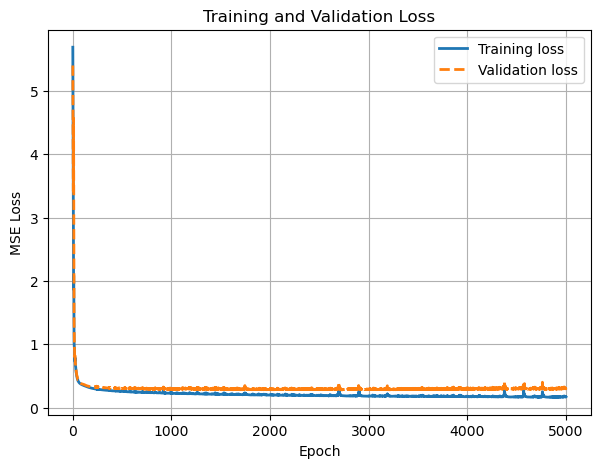

In [14]:
### Plot training and validation loss
###
### A good training curve should generally decrease.
###
### If training loss decreases but validation loss increases,
### the model may be overfitting.

plt.figure(figsize=(7, 5))

plt.plot(
    train_losses,
    label="Training loss",
    linewidth=2
)

plt.plot(
    val_losses,
    label="Validation loss",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
### Make prediction on test data
###
### model.eval():
###     switch to evaluation mode
###
### torch.no_grad():
###     disable gradient computation because we are not training

model.eval()

with torch.no_grad():
    y_test_pred_tensor = model(X_test_tensor)

### Convert PyTorch tensors to NumPy arrays for sklearn metrics and plotting
###
### detach():
###     removes tensor from the computation graph
###
### numpy():
###     converts tensor to NumPy array

y_test_pred = y_test_pred_tensor.detach().numpy()
y_test_true = y_test_tensor.detach().numpy()

mse = mean_squared_error(y_test_true, y_test_pred)
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)

print("Test MSE:", mse)
print("Test MAE:", mae)
print("Test R2:", r2)


Test MSE: 0.45282554626464844
Test MAE: 0.3565943241119385
Test R2: 0.6608530879020691


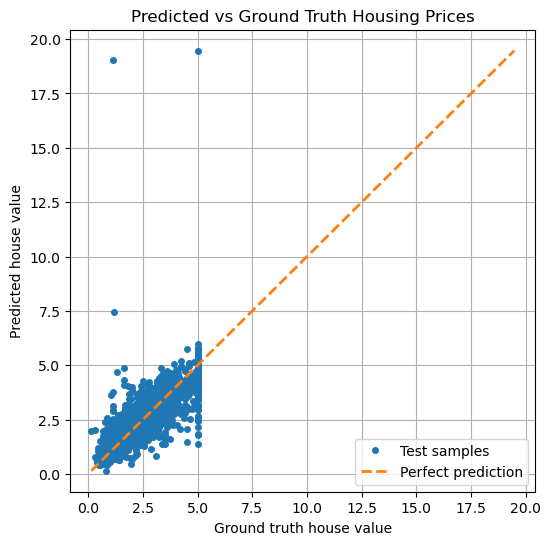

In [16]:
### Plot prediction against ground truth
###
### Each point is one test sample.
###
### If the model is accurate:
###     points should be close to the diagonal line y = x.
###
### The diagonal line is not a model prediction.
### It is only a visual reference for perfect prediction.

plt.figure(figsize=(6, 6))

plt.plot(
    y_test_true,
    y_test_pred,
    "o",
    markersize=4,
    label="Test samples"
)

### Create diagonal reference line
min_value = min(y_test_true.min(), y_test_pred.min())
max_value = max(y_test_true.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Ground truth house value")
plt.ylabel("Predicted house value")
plt.title("Predicted vs Ground Truth Housing Prices")
plt.legend()
plt.grid(True)
plt.show()
